# 📧 SMS Spam Classifier — My First Machine Learning Project

A machine learning model that classifies SMS messages as **spam** or **ham** (legitimate). This is my first ML project, built using scikit-learn after completing two pandas-focused projects.

## 🎯 Final Results
- **Accuracy:** 96.90% on unseen test data
- **Spam precision:** 1.00 (zero false alarms — never flags a real message as spam)
- **Spam recall:** 0.76 (catches 76% of spam; the other 24% are mostly modern-style spam not present in the training data)
- **Ham recall:** 1.00 (legitimate messages always reach the user)

## 📊 Dataset
- **Name:** SMS Spam Collection
- **Source:** https://www.kaggle.com/datasets/ashfakyeafi/spam-email-classification
- **Size:** 5,572 messages (5,157 after removing 415 duplicates)
- **Distribution:** 87% ham, 13% spam (moderately imbalanced)

## 🛠️ Approach
1. **Explore** the data (pandas)
2. **Clean** — drop duplicates, remove malformed rows
3. **Vectorize** text using TF-IDF (turn words into numbers)
4. **Split** into 80% training / 20% testing sets
5. **Train** a Multinomial Naive Bayes classifier
6. **Evaluate** with accuracy, precision, recall, F1-score
7. **Stress-test** with custom messages

## 🧠 What I Learned
- How TF-IDF converts text into numerical features
- The crucial difference between `fit_transform` (training only) and `transform` (everything else)
- Why train/test splitting prevents the model from "memorizing"
- That accuracy alone hides the full picture — precision and recall matter
- That ML models are only as good as their training data (a model trained on 2002 SMS spam doesn't know about iPhone scams)

## 1. Loading the Data

Loading the SMS Spam Collection dataset with pandas. The dataset uses `latin-1` encoding to handle special characters in some messages.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("email.csv")
df.head(10)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## 2. Exploring the Dataset

Before building any model, I need to understand what's in the data: column names, types, class balance, and example messages. This is where I caught a malformed row in the `Category` column (a stray JSON fragment) that I'll drop later.

In [3]:
df.shape

(5573, 2)

## 3. Cleaning the Data

The raw dataset has two issues:

- **One malformed row** in the Category column (looks like a stray JSON entry)
- **415 duplicate rows** — exact same messages appearing more than once, which would bias the model toward those repeated patterns

Removing both gives a clean dataset of 5,157 unique, valid messages.

In [4]:
df["Category"].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [6]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [7]:

df[df["Category"] == "spam"]["Message"].head(5).values

<ArrowStringArray>
[  'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's',
           'FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv',
 'WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.',
    'Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030',
                      'SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info']
Length: 5, dtype: str

In [8]:

df[df["Category"] == '{"mode":"full"']

,Category,Message
5572,"{""mode"":""full""",isActive:false}


In [10]:
df = df[df["Category"].isin(["ham","spam"])]
df["Category"].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [11]:
df.duplicated().sum()

np.int64(415)

In [12]:
df["length"] = df["Message"].str.len()

In [14]:
df.groupby("Category")["length"].mean()

Category
ham      71.44829
spam    137.98929
Name: length, dtype: float64

In [15]:
df = df.drop_duplicates()

In [16]:
df["Category"].value_counts()

Category
ham     4516
spam     641
Name: count, dtype: int64

In [17]:
X = df["Message"]
y = df["Category"]

print("X shape: ", X.shape)
print("y shape: ", y.shape)


X shape:  (5157,)
y shape:  (5157,)


## 4. Vectorizing Text → Numbers

Machine learning models can't read text directly. They need numbers. I'm using **TF-IDF (Term Frequency – Inverse Document Frequency)** to convert each message into a numerical vector.

In plain English: each message becomes a long list of numbers, where each number represents how "important" each word is in that message. Common words like "the" or "and" get low scores (they appear everywhere). Rare-but-meaningful words get high scores.

After vectorizing, each of the 5,157 messages is represented as a vector of ~7,000 numbers (one per unique word in the vocabulary).

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", lowercase= True)

X_vectorized = vectorizer.fit_transform(X)

print("shape of X:", X.shape)
print("shape of X vectorized:", X_vectorized.shape)


shape of X: (5157,)
shape of X vectorized: (5157, 8440)


## 5. Splitting into Training and Test Sets

A model that's evaluated on the data it was trained on will look perfect — it just memorized the answers. To honestly measure how well the model generalizes to new messages, I hold back 20% of the data as a **test set** that the model never sees during training.

The `random_state=42` argument ensures reproducibility: every run produces the exact same split.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

print("x train shape:", X_train.shape)
print("x test shape:", X_test.shape)
print("y train shape:", y_train.shape)
print("y test shape:", y_test.shape)

x train shape: (4125, 8440)
x test shape: (1032, 8440)
y train shape: (4125,)
y test shape: (1032,)


## 6. Training the Model

I'm using **Multinomial Naive Bayes** — a classic, fast algorithm that's especially good at text classification. Despite its "naive" simplifying assumption (it treats each word independently), it works remarkably well on spam classification and was one of the breakthrough techniques behind early spam filters in the 1990s.

Two lines is all it takes: create the model, then `fit()` it on the training data.

In [21]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)
print("Model trained!!!")



Model trained!!!


## 7. Evaluating the Model

Now I measure how well the trained model performs on the 1,032 messages it has never seen.

I look at multiple metrics:

- **Accuracy** — overall correctness, but can be misleading on imbalanced data
- **Precision** — when the model predicts "spam," how often is it right?
- **Recall** — of all actual spam, how much does the model catch?
- **F1-score** — balanced average of precision and recall

In [22]:
from sklearn.metrics import accuracy_score, classification_report

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 96.90%


In [23]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       896
        spam       1.00      0.76      0.87       136

    accuracy                           0.97      1032
   macro avg       0.98      0.88      0.92      1032
weighted avg       0.97      0.97      0.97      1032



## 9. Testing on My Own Messages

To see how the model handles brand-new inputs, I wrote a few test messages — both clearly legitimate and clearly spammy.

⚠️ **Important detail:** I use `vectorizer.transform()` here, NOT `fit_transform()`. The vectorizer already learned the vocabulary from training; I just want to convert new messages using that same vocabulary. Using `fit_transform` here would re-learn the vocabulary from these 8 messages alone, breaking everything.

In [25]:
test_messages = [
    "Hey, are we still meeting at 7?",
    "WIN A FREE iPHONE!!! Click here NOW: bit.ly/winwin",
    "Don't forget your homework",
    "URGENT: Your account has been compromised. Send your password.",
    "lol that's hilarious 😂",
    "Congratulations! You've won £1000. Reply YES to claim.",
    "Mom says dinner is ready",
    "Free entry in our weekly competition! Text WIN to 80008",
]

test_vectorized = vectorizer.transform(test_messages)

test_prediction = model.predict(test_vectorized)

for message, prediction in zip(test_messages, test_prediction):
    print(f"{[prediction.upper()]} {message}")

['HAM'] Hey, are we still meeting at 7?
['HAM'] WIN A FREE iPHONE!!! Click here NOW: bit.ly/winwin
['HAM'] Don't forget your homework
['HAM'] URGENT: Your account has been compromised. Send your password.
['HAM'] lol that's hilarious 😂
['SPAM'] Congratulations! You've won £1000. Reply YES to claim.
['HAM'] Mom says dinner is ready
['SPAM'] Free entry in our weekly competition! Text WIN to 80008


In [26]:
test_messages_2 = [
    "Free ringtones! Reply TONE to 80188 to download",
    "U have won a £900 prize. Call 09061740495 now",
    "wkly comp - text WIN to 84128 for ur chance",
    "Hey mate, see u at the pub at 8",
    "ok i'll bring the books",
]

test_vec_2 = vectorizer.transform(test_messages_2)
predictions_2 = model.predict(test_vec_2)

for msg, pred in zip(test_messages_2, predictions_2):
    print(f"[{pred.upper()}] {msg}")

[SPAM] Free ringtones! Reply TONE to 80188 to download
[SPAM] U have won a £900 prize. Call 09061740495 now
[SPAM] wkly comp - text WIN to 84128 for ur chance
[HAM] Hey mate, see u at the pub at 8
[HAM] ok i'll bring the books


### What I observed

The model successfully caught some spam (the "Congratulations! You've won £1000" message), but **missed two clearly spam-like messages**:

- ❌ "WIN A FREE iPHONE!!! Click here NOW: bit.ly/winwin"
- ❌ "URGENT: Your account has been compromised. Send your password."

**Why this happens:** The SMS Spam Collection dataset is from ~2002 — before iPhones, before URL shorteners like bit.ly, before modern phishing tactics. The model never learned that "iphone" or "bit.ly" or "compromised account" are spam signals because those words barely appear (or don't appear at all) in its training data.

**The lesson:** A machine learning model is only as good as the data it was trained on. To detect modern spam, the training data would need to be updated with recent examples — a process real production spam filters do continuously.

This is a real ML phenomenon called **distribution shift** — when the data the model sees in production differs from the data it was trained on, performance drops.

## 8. Confusion Matrix — Visualizing the Errors

The confusion matrix shows exactly where the model succeeds and fails.

- **Top-left:** Ham correctly identified
- **Top-right:** Ham wrongly flagged as spam (false positives — would block real messages)
- **Bottom-left:** Spam that slipped through (false negatives — would arrive in inbox)
- **Bottom-right:** Spam correctly caught

My model's profile: zero false positives (good for users — no legit messages blocked), but ~33 spam messages slip through (~24% of actual spam).

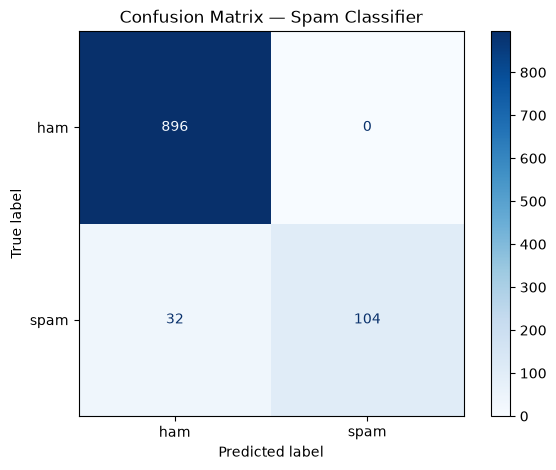

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, predictions, labels=["ham", "spam"])

# Display it nicely
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(ax=ax, cmap="Blues", colorbar=True)
plt.title("Confusion Matrix — Spam Classifier")
plt.show()